For Logistic Regression, we'll normalize the data columns, which are not normalized

We will also use AgeGroup as a column and feed it to the model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_data.csv')
df.sample()

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
34873,34,1.0,0,0,0,0.106323,0,7100.0,6,0,2.0,1


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

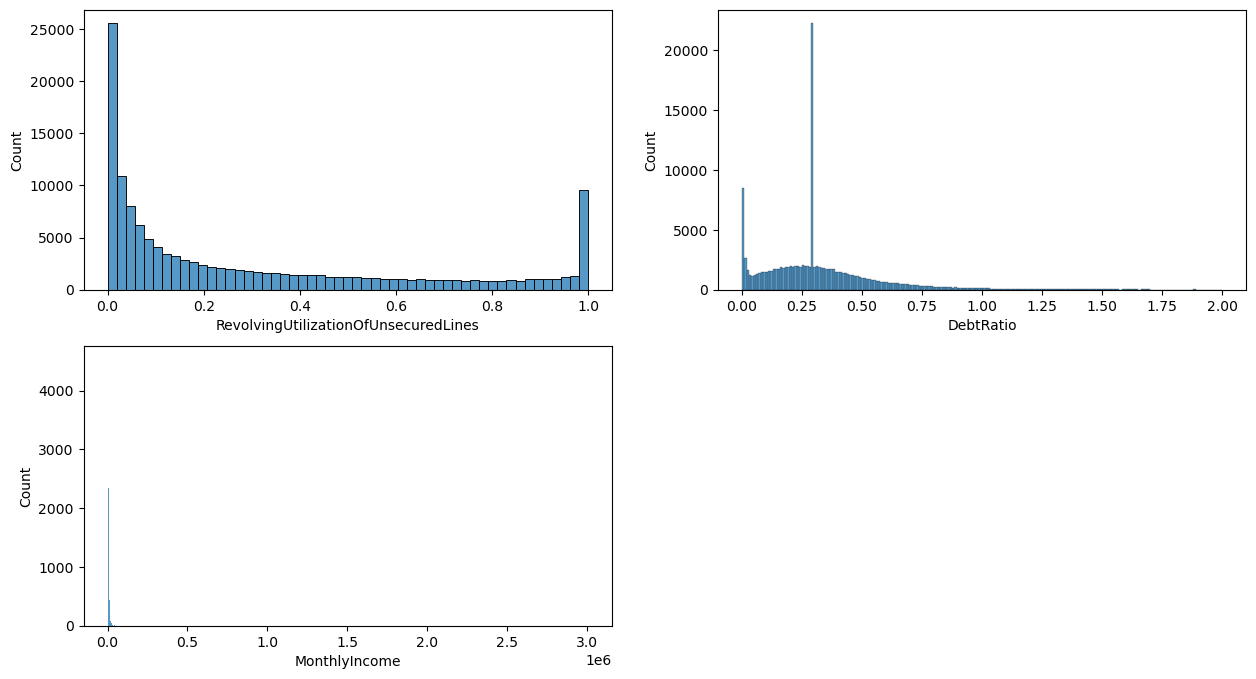

In [3]:
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
sns.histplot(x='RevolvingUtilizationOfUnsecuredLines',data=df)

plt.subplot(2,2,2)
sns.histplot(x='DebtRatio',data=df)

plt.subplot(2,2,3)
sns.histplot(x='MonthlyIncome',data=df)

In [4]:
df['LogIncome'] = np.log(df['MonthlyIncome'])

<Axes: xlabel='LogIncome', ylabel='Count'>

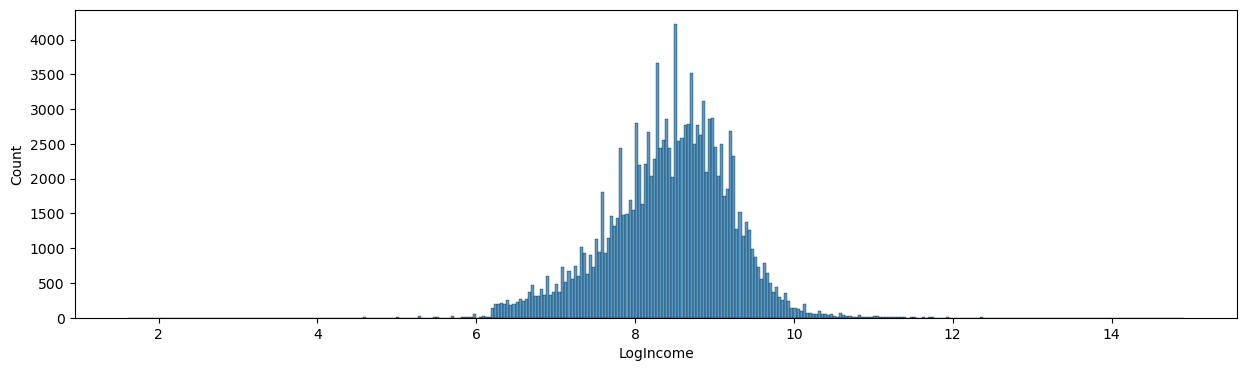

In [5]:
plt.figure(figsize=(15,4))
sns.histplot(x='LogIncome',data=df)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134206 entries, 0 to 134205
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   134206 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  134206 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  134206 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  134206 non-null  int64  
 4   NumberOfTimes90DaysLate               134206 non-null  int64  
 5   DebtRatio                             134206 non-null  float64
 6   DebtRatioMissing                      134206 non-null  int64  
 7   MonthlyIncome                         134206 non-null  float64
 8   NumberOfOpenCreditLinesAndLoans       134206 non-null  int64  
 9   NumberRealEstateLoansOrLines          134206 non-null  int64  
 10  NumberOfDependents                    134206 non-null  float64
 11  

In [7]:
df.drop(['MonthlyIncome'],axis=1,inplace=True)

<Axes: xlabel='NumberOfTimes90DaysLate', ylabel='Count'>

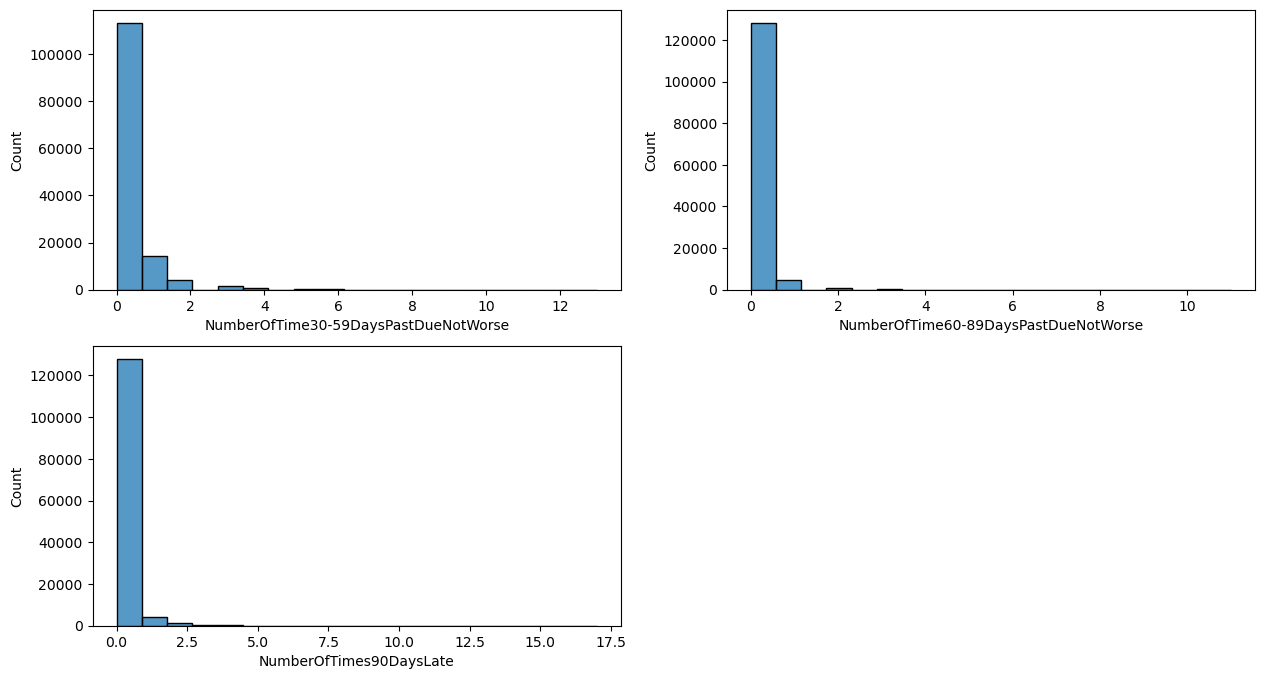

In [8]:
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
sns.histplot(x='NumberOfTime30-59DaysPastDueNotWorse',data=df)

plt.subplot(2,2,2)
sns.histplot(x='NumberOfTime60-89DaysPastDueNotWorse',data=df)

plt.subplot(2,2,3)
sns.histplot(x='NumberOfTimes90DaysLate',data=df)

<Axes: xlabel='NumberOfDependents', ylabel='Count'>

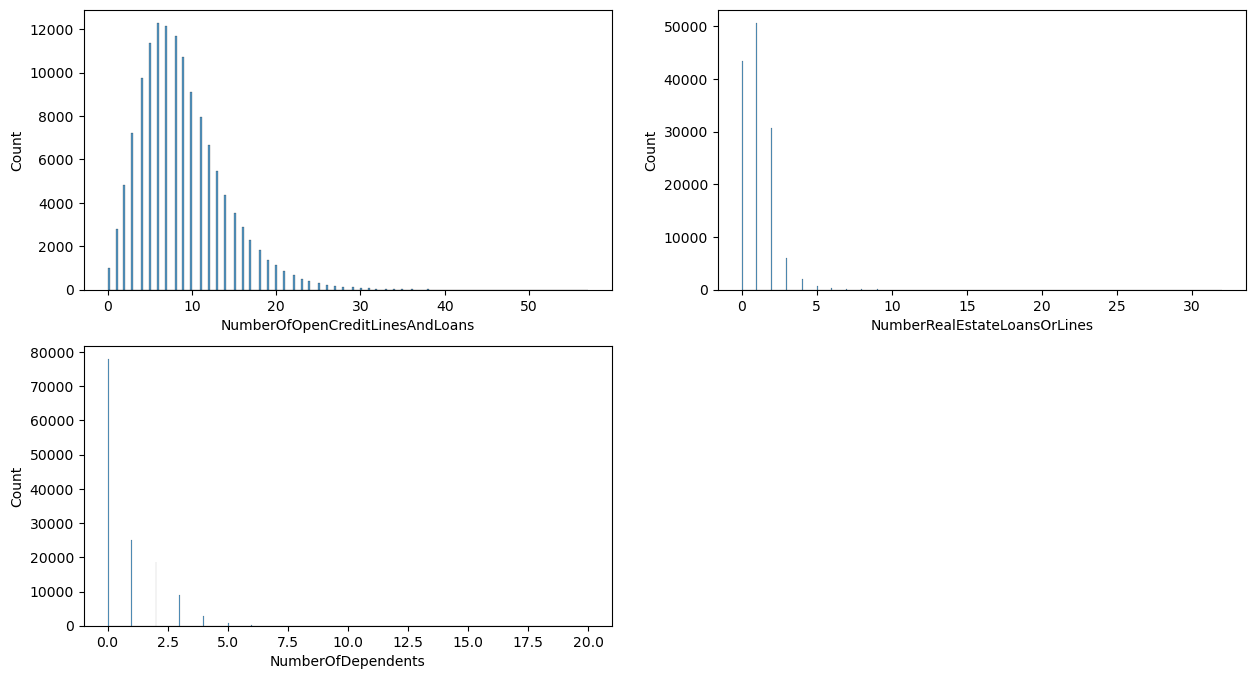

In [9]:
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
sns.histplot(x='NumberOfOpenCreditLinesAndLoans',data=df)

plt.subplot(2,2,2)
sns.histplot(x='NumberRealEstateLoansOrLines',data=df)

plt.subplot(2,2,3)
sns.histplot(x='NumberOfDependents',data=df)

<Axes: >

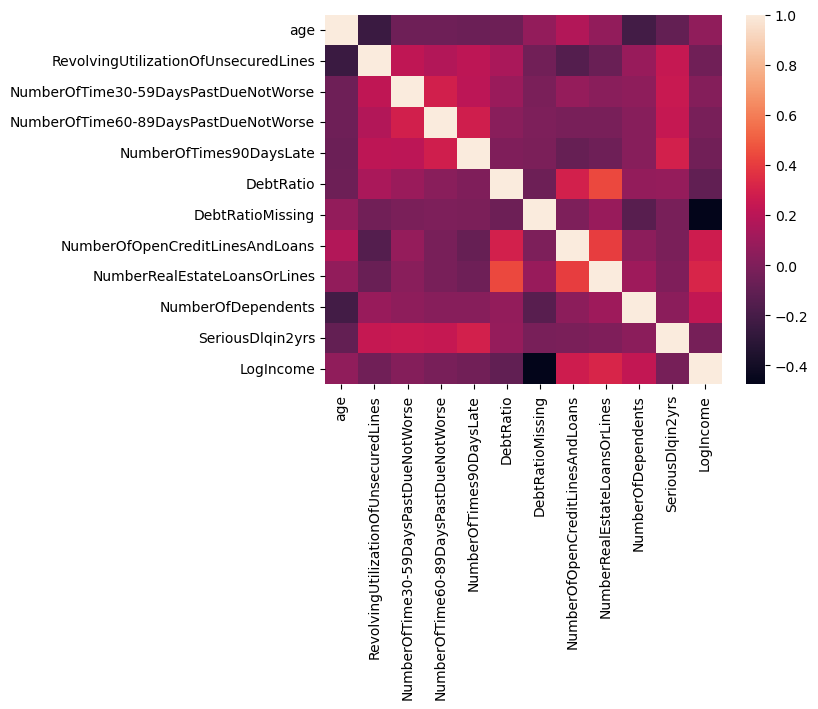

In [10]:
sns.heatmap(df.corr())

Numeric:- Age, Utilization, Debt Ratio, LogIncome

Categorical:- NumberOfTimes (all three), Debt Ratio Missing (0 or 1), Number Of lines (Credit and estate), Number of dependents

Target: SeriousDlqin2yrs

<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

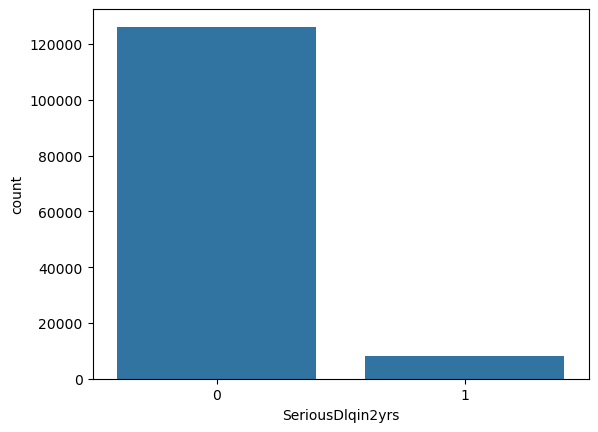

In [11]:
sns.countplot(x='SeriousDlqin2yrs',data=df)

In [12]:
df.groupby('SeriousDlqin2yrs')['SeriousDlqin2yrs'].count()

SeriousDlqin2yrs
0    126189
1      8017
Name: SeriousDlqin2yrs, dtype: int64

In [13]:
126189/8017

15.740177123612323

**We'll create LogisticRegression model where class weight for class 0 is 1 and class 1 is 15.74**

In [14]:
bins = [19, 35, 50, 65, float('inf')]
labels = ['Young', 'Middle-aged', 'Senior', 'Old']

df['AgeGroup'] = pd.cut(df['age'],bins=bins,labels=labels)

**StandardScaler**: age, RevolvingUtilizationOfUnsecuredLines, LogIncome, NumberOfOpenCreditLinesAndLoans

**RobustScaler**: DebtRatio, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate, 
              NumberRealEstateLoansOrLines, NumberOfDependents

**OHE**: AgeGroup

**Pass through**: DebtRatioMissing

In [15]:
df.columns

Index(['age', 'RevolvingUtilizationOfUnsecuredLines',
       'NumberOfTime30-59DaysPastDueNotWorse',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
       'DebtRatio', 'DebtRatioMissing', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'SeriousDlqin2yrs', 'LogIncome', 'AgeGroup'],
      dtype='object')

In [16]:
df = df[['age', 'RevolvingUtilizationOfUnsecuredLines',
       'NumberOfTime30-59DaysPastDueNotWorse',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
       'DebtRatio', 'DebtRatioMissing', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents','LogIncome', 'AgeGroup','SeriousDlqin2yrs']]

In [17]:
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [18]:
Transformer = ColumnTransformer([
    ('StandardScaling',StandardScaler(),['age', 'RevolvingUtilizationOfUnsecuredLines', 'LogIncome', 'NumberOfOpenCreditLinesAndLoans']),
    ('RobustScaling',RobustScaler(),['DebtRatio', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 
                                     'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']),
    ('OHE',OneHotEncoder(drop='first',sparse_output=False),['AgeGroup'])
],remainder='passthrough')

In [19]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [20]:
X.shape, y.shape

((134206, 12), (134206,))

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
from sklearn.pipeline import Pipeline

In [25]:
Logistic_pipe = Pipeline(
    [
     ('Preprocessing',Transformer),
     ('Logistic Model',LogisticRegression(class_weight={0:1,1:15.74}))
    ]
)

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
Logistic_parameters = {
    'Logistic Model__C':[100,10,1,0.1,0.01]
    }

Logistic_grid = GridSearchCV(Logistic_pipe,param_grid=Logistic_parameters,scoring='recall')

In [28]:
Logistic_grid.fit(X_train,y_train)

C:\Users\bhavy\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('Preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('StandardScaling',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'RevolvingUtilizationOfUnsecuredLines',
                                                                          'LogIncome',
                                                                          'NumberOfOpenCreditLinesAndLoans']),
                                                                        ('RobustScaling',
                                                                         RobustScaler(),
                                                                         ['DebtRatio',
                                                                          'NumberOfTime30-59DaysPastDueNotWorse',
                                                                          'NumberOfTime60-89DaysPastDueNotWorse',
                                                                          'NumberOfTimes90DaysLate',
                                                                          'NumberRealEstateLoansOrLines',
                                                                          'NumberOfDependents']),
                                                                        ('OHE',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['AgeGroup'])])),
                                       ('Logistic Model',
                                        LogisticRegression(class_weight={0: 1,
                                                                         1: 15.74}))]),
             param_grid={'Logistic Model__C': [100, 10, 1, 0.1, 0.01]},
             scoring='recall')

In [29]:
Logistic_grid.best_params_

{'Logistic Model__C': 0.01}

In [30]:
y_preds = Logistic_grid.predict(X_test)

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [32]:
accuracy_score(y_test,y_preds)

0.7939616118264187

In [33]:
print('Confusion Matrix')
print(confusion_matrix(y_test,y_preds))

Confusion Matrix
[[25226  6378]
 [  535  1413]]


False negatives are **535**

False negative here means that we predict customer is non-deliquent but actually is deliquent

In [34]:
print('Classification report')
print(classification_report(y_test,y_preds))

Classification report
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     31604
           1       0.18      0.73      0.29      1948

    accuracy                           0.79     33552
   macro avg       0.58      0.76      0.58     33552
weighted avg       0.93      0.79      0.85     33552



Recall is 73%

In [35]:
logistic_model = Logistic_grid.best_estimator_

In [37]:
import pickle

# save using pickle


with open("final_logistic_model.pkl", "wb") as f:
    pickle.dump(logistic_model, f)

Note:- We'll have to take np.log of income of input when using the model and also assign the age group according to age input by user